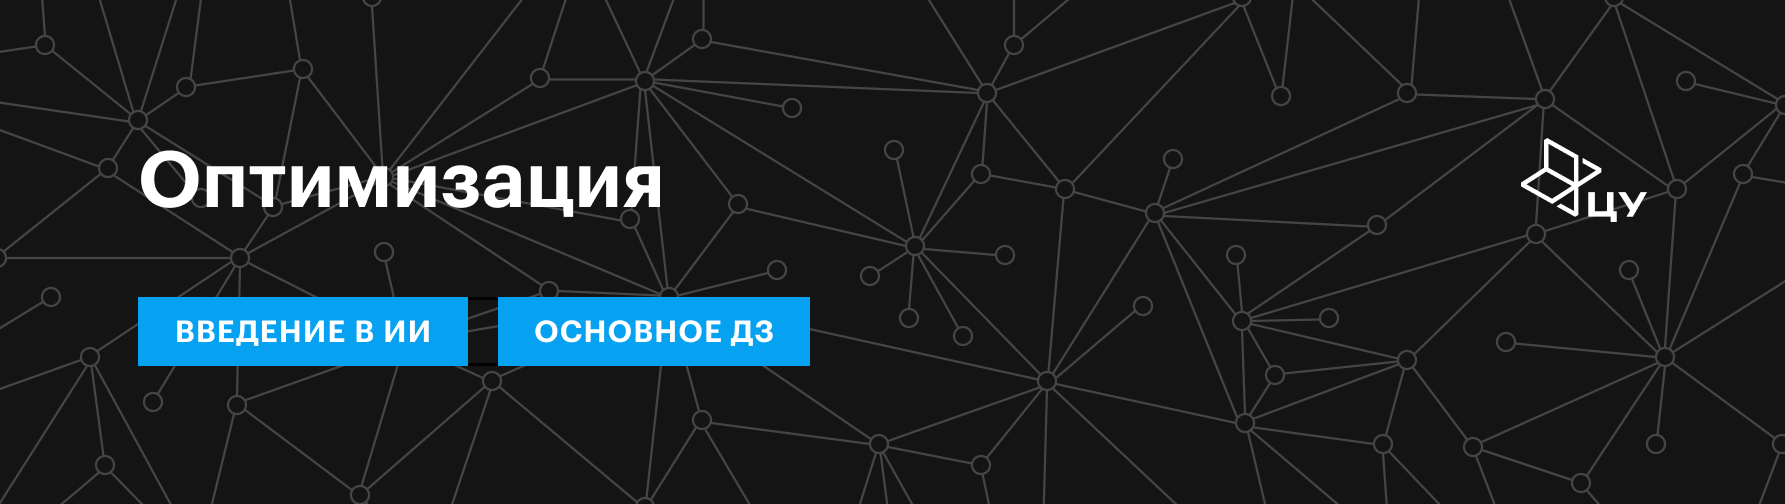

# Домашнее задание по теме «Оценка моделей и подбор гиперпараметров»

В этом задании ты продолжишь работу с датасетом Student Depression и закрепишь:
- подбор гиперпараметров с помощью k-fold кросс-валидации;
- интервальную оценку качества с помощью бутстреп.


> ### Правила домашнего задания
>
>1. Нельзя удалять существующие ячейки кода.
>
>2. Можно добавлять и дописывать свои ячейки.
>
>3. Место, куда тебе нужно написать код, помечается комментарием.
>
> 4. Ответ без кода, который подтвердит твоё решение, не засчитывается. Исключение — задачи и вопросы, где код не требуется и нужно сделать вывод из известных данных.
>
> 5. Код должен быть работоспособным. У проверяющих должна быть возможность воспроизвести все полученные результаты.
>
> 6. Все графики подписывай так, чтобы можно было легко понять их суть. Избегай слишком мелкого или крупного текста, подписывай оси на одном языке.
>
> 7. Фиксируй seed random для воспроизводимости результатов.


## Установка библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

SEED = 21
np.random.seed(SEED)


## Задание 1 [0,5 балла]

Подготовь данные для обучения моделей на датасете Student Depression, который был в прошлом домашнем задании.

1. Скачай датасет и загрузи его в `df` — **[0,1 балла]**.
2. Сделай `id` индексом или удали колонку `id` — **[0,1 балла]**.
3. Обработай пропуски (например, удалением строк или заполнением) — **[0,1 балла]**.
4. Закодируй категориальные признаки (например, `pd.get_dummies`) и получи `df_encoded` — **[0,1 балла]**.
5. Отдели таргет (`Depression`) от признаков и посчитай долю студентов с депрессией — **[0,1 балла]**.

In [2]:
# Скачай датасет
!gdown 1VulOU7P9Tfisb4nazeFxny__5zJ9zPkd


Downloading...
From: https://drive.google.com/uc?id=1VulOU7P9Tfisb4nazeFxny__5zJ9zPkd
To: /content/Student Depression Dataset.csv
100% 2.81M/2.81M [00:00<00:00, 53.7MB/s]


In [3]:
# Напиши код здесь
df = pd.read_csv("/content/Student Depression Dataset.csv")

df = df.drop(columns="id")
df = df.drop(columns = ["City", "Profession"])
df = df.dropna()
df['Have you ever had suicidal thoughts ?'] = (df['Have you ever had suicidal thoughts ?'] == "Yes").astype(int)
df['Family History of Mental Illness'] = (df['Family History of Mental Illness'] == "Yes").astype(int)
df['Gender'] = (df['Gender'] == "Male").astype(int)


In [4]:
display(df)

,Gender,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,1,33.0,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,1,3.0,1.0,0,1
1,0,24.0,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,0,3.0,2.0,1,0
2,1,31.0,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,0,9.0,1.0,1,0
3,0,28.0,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,1,4.0,5.0,1,1
4,0,25.0,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,1,1.0,1.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,0,27.0,5.0,0.0,5.75,5.0,0.0,5-6 hours,Unhealthy,Class 12,1,7.0,1.0,1,0
27897,1,27.0,2.0,0.0,9.40,3.0,0.0,Less than 5 hours,Healthy,MSc,0,0.0,3.0,1,0
27898,1,31.0,3.0,0.0,6.61,4.0,0.0,5-6 hours,Unhealthy,MD,0,12.0,2.0,0,0
27899,0,18.0,5.0,0.0,6.88,2.0,0.0,Less than 5 hours,Healthy,Class 12,1,10.0,5.0,0,1


In [5]:
df = pd.get_dummies(data=df, drop_first=True, columns=["Sleep Duration", "Dietary Habits", "Degree"])

In [6]:
display(df)

,Gender,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,...,Degree_MA,Degree_MBA,Degree_MBBS,Degree_MCA,Degree_MD,Degree_ME,Degree_MHM,Degree_MSc,Degree_Others,Degree_PhD
0,1,33.0,5.0,0.0,8.97,2.0,0.0,1,3.0,1.0,...,False,False,False,False,False,False,False,False,False,False
1,0,24.0,2.0,0.0,5.90,5.0,0.0,0,3.0,2.0,...,False,False,False,False,False,False,False,False,False,False
2,1,31.0,3.0,0.0,7.03,5.0,0.0,0,9.0,1.0,...,False,False,False,False,False,False,False,False,False,False
3,0,28.0,3.0,0.0,5.59,2.0,0.0,1,4.0,5.0,...,False,False,False,False,False,False,False,False,False,False
4,0,25.0,4.0,0.0,8.13,3.0,0.0,1,1.0,1.0,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,0,27.0,5.0,0.0,5.75,5.0,0.0,1,7.0,1.0,...,False,False,False,False,False,False,False,False,False,False
27897,1,27.0,2.0,0.0,9.40,3.0,0.0,0,0.0,3.0,...,False,False,False,False,False,False,False,True,False,False
27898,1,31.0,3.0,0.0,6.61,4.0,0.0,0,12.0,2.0,...,False,False,False,False,True,False,False,False,False,False
27899,0,18.0,5.0,0.0,6.88,2.0,0.0,1,10.0,5.0,...,False,False,False,False,False,False,False,False,False,False


In [7]:

# df_encoded = ...

# Отдели признаки от таргета
X, y = df.drop(columns="Depression"), df["Depression"]
y.mean()

np.float64(0.5855258441465337)

## Задание 2 [0,5 балла]

Обучи две модели машинного обучения. Можешь взять те же модели, что и в предыдущем домашнем задании.

1. Разбей датасет на train и test.
2. Обучи две модели.
3. Посчитай `Accuracy` на train и test для каждой модели. Являются ли какие-то из них переобученными? Оставь ответ в текстовом блоке.


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=171)

In [10]:


logic_model = LogisticRegression()
logic_model.fit(X_train, y_train)

ans_train = logic_model.predict(X_train)
ans_test = logic_model.predict(X_test)

print(accuracy_score(ans_train, y_train))
print(accuracy_score(ans_test, y_test))

0.8460883591719688
0.8543010752688172


Кажется, модель нормальная и не переобучена

In [11]:
tree_model = RandomForestClassifier()
tree_model.fit(X_train, y_train)

train_preds = tree_model.predict(X_train)
val_preds = tree_model.predict(X_test)

acc = accuracy_score(train_preds, y_train)
print(acc)
acc = accuracy_score(val_preds, y_test)
print(acc)


0.9999551931176629
0.8473118279569892


Явно переобучена


#### Напиши ответ на вопрос здесь

## Задание 3 [3 балла]

Подбери гиперпараметры для обеих моделей с помощью k-fold кросс-валидации.

1. Задай сетки гиперпараметров — **[1 балл]**.
2. Запусти `GridSearchCV` (или `RandomizedSearchCV`) с `cv=5` — **[1 балл]**.
3. Выведи: лучшие гиперпараметры, среднее качество по фолдам и стандартное отклонение — **[1 балл]**.

Подсказка. Можно попробовать перебрать следующие параметры.

* Деревья решений: `max_depth`, `min_samples_leaf`, `min_samples_split`, `max_features`.

* Случайный лес (Random Forest): `n_estimators`, `max_depth`, `max_features`, `min_samples_leaf`.

* Линейные модели (Logistic Regression, Ridge, Lasso): `C`.

* Градиентный бустинг (XGBoost, LightGBM, CatBoost): `n_estimators`, `max_depth`.

In [12]:
from sklearn.model_selection import GridSearchCV

In [13]:
param = {"C": [0.01, 0.1, 1, 10]}

lgrid = GridSearchCV(LogisticRegression(), param, cv = 5)
lgrid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [0.01, 0.1, 1, 10]})

In [14]:
print(lgrid.best_params_)
print(lgrid.best_score_)
print(lgrid.cv_results_["std_test_score"][lgrid.best_index_])

{'C': 0.1}
0.8455958369773937
0.0036096559268578294


In [15]:
params = {
    "max_depth": [3, 5, None],
    "min_samples_leaf": [1, 3],
    "min_samples_split": [2, 4]
}

tgrid = GridSearchCV(RandomForestClassifier(), params, cv=5)
tgrid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [3, 5, None], 'min_samples_leaf': [1, 3],
                         'min_samples_split': [2, 4]})

In [16]:
print(tgrid.best_params_)
print(tgrid.best_score_)
print(tgrid.cv_results_["std_test_score"][tgrid.best_index_])

{'max_depth': None, 'min_samples_leaf': 3, 'min_samples_split': 2}
0.8432660176023168
0.0053878846347734976


## Задание 4 [2 балла]

Оцени лучших представителей среди двух выбранных семейств моделей на тестовой выборке.

1. Обучи каждую лучшую модель на `X_train`, `y_train` — **[1 балл]**.
2. Посчитай на тесте: `Accuracy`, `Precision` и `Recall` — **[1 балл]**.


In [17]:
from sklearn.metrics import precision_score, recall_score

In [18]:
logic_model = lgrid.best_estimator_
forest_model = tgrid.best_estimator_

a = logic_model.predict(X_test)
b = forest_model.predict(X_test)
print(f"logic: {accuracy_score(a, y_test):.2f} forest: {accuracy_score(b, y_test):.2f}")
print(f"logic: {precision_score(a, y_test):.2f} forest: {precision_score(b, y_test):.2f}")
print(f"logic: {recall_score(a, y_test):.2f} forest: {recall_score(b, y_test):.2f}")

logic: 0.85 forest: 0.85
logic: 0.90 forest: 0.90
logic: 0.86 forest: 0.86


Логическая будто бы получше

## Задание 5 [3 балла]

Построй интервальную оценку качества для лучшей модели с помощью бутстрепа.

1. Реализуй бутстреп-оценку `Accuracy` (например, 50–300 выборок) — **[1 балл]**.
2. Построй 95-процентный доверительный интервал и гистограмму значений метрики для двух наилучших моделей — **[2 балла]**.

Вспомним идею бутстрепа:  
- берём выборку с повторениями — используем её как обучающую выборку;  
- объекты, которые не попали в выборку bootstrap sample, используем для тестовой выборки;  
- повторяем этот процесс много раз — получаем распределение значений метрики качества.


In [31]:
def bootstrap(model, X, y):
  scores = np.zeros(100)
  for i in range(100):
    train = np.random.choice(np.arange(len(X)), size=len(X), replace=True)

    test = np.ones(len(X), dtype=bool)
    test[train] = False

    X_train, X_test = X.iloc[train], X.iloc[test]
    y_train, y_test = y.iloc[train], y.iloc[test]

    model.fit(X_train, y_train)
    res = model.predict(X_test)
    scores[i] = accuracy_score(y_test, res)
  return scores

In [32]:
logic_scores = bootstrap(logic_model, X, y)
forest_scores = bootstrap(forest_model, X, y)

[0.84173961 0.85216503]
[0.8365202  0.84913156]


(array([ 3.,  9., 11., 15., 20., 19., 15.,  5.,  0.,  3.]),
 array([0.83464567, 0.83634697, 0.83804826, 0.83974956, 0.84145085,
        0.84315215, 0.84485344, 0.84655474, 0.84825604, 0.84995733,
        0.85165863]),
 <BarContainer object of 10 artists>)

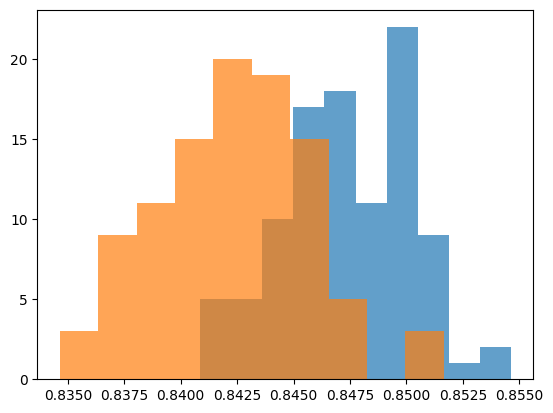

In [33]:
print(np.percentile(logic_scores, [2.5, 97.5]))

plt.hist(logic_scores, alpha = 0.7)
print(np.percentile(forest_scores, [2.5, 97.5]))
plt.hist(forest_scores, alpha = 0.7)

## Задание 6 [1 балл]

Проверь и сравни модели.

1. Сравни две обученные модели по ширине доверительного интервала — **[0,5 балла]**.
2. Напиши вывод: можно ли уверенно сказать, что одна модель лучше другой? — **[0,5 балла]**.


1. Да, у модели леса интервал смещен левее, чем у логистической регрессии.
2. Нет, так как распределения пусть и смещены друг относительно друга, мы не знаем правильный ответ, а распределения выглядят нормальнор, поэтому нельзя сказать, что одно лучше другого